In [1]:
#%%
import numpy as np
import os
import time
import matplotlib.pyplot as plt
# from FFNN_model_caller import FFNN
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
from scipy import signal
from scipy.stats import linregress
from scipy.io import savemat
import math




def get_data_in_array(dataframe,header_name,delim = True,size=400):
    # print(len(dataframe))
    _results_array = np.zeros([len(dataframe),size])
    # print(_results_array.shape)
    for i in range(0,len(dataframe)):
        _results = dataframe[header_name].iloc[i]
        # Remove any leading or trailing whitespace from the string
        _results = _results.strip()
        # Remove the square brackets from the string 
        _results = _results[1:-1]
        # Split the string by comma to get individual values as strings
        if delim:
            _results = _results.split(",")
        else:
            _results = _results.split()
        # Convert the string values to float type and create a NumPy array
        np_array = [float(value.strip()) for value in _results]

        _results_array[i] = np.array(np_array)[:400]
    print("efew")
    print(_results_array.shape)
    return _results_array

def get_data(path): 
    
    dataset = pd.read_csv(path, skiprows=[0], names=['Numbers','Frequencies','Powers','arcsin_results','test_data','expected_recovered_freq'])
    dataset = dataset.sort_values(by=['Frequencies','Powers'],ignore_index=True)
    dataset = dataset.drop_duplicates(subset=['Frequencies','Powers'],keep='first',ignore_index=True)
    print(dataset.head(5))
    print(dataset.tail(5))
    x = get_data_in_array(dataframe=dataset,header_name='arcsin_results',delim = True).astype(float)
    print("??????????")
    print(x.shape[0])
    x = np.resize(x, (x.shape[0], 400))
    print(x.shape)
    test_data = get_data_in_array(dataframe=dataset,header_name='test_data',delim = True).astype(float)
    test_data = np.resize(test_data, (test_data.shape[0], 400))
    #test_data = normalize_vector(test_data)
   
    return x,test_data,dataset
#%%
def fft_signal(data_,iota):
    """
    scaling{ ‘density’, ‘spectrum’ }, optional Selects between computing the power spectral density (‘density’) 
    where Pxx has units of V**2/Hz and computing the power spectrum (‘spectrum’) where Pxx has units of V**2, 
    if x is measured in V and fs is measured in Hz. Default is set to ‘density’.
    """
    N = 2**math.ceil(math.log2(len(data_) * 4))
    f, x = signal.periodogram(data_, window='hann',nfft = N,fs=1e9*iota, scaling='spectrum')
    f = f/1e6
    epsilon = 1e-10 ## Add a small constant to avoid division by zero or logarithm of zero
    x = 10*(np.log10(np.divide(x+epsilon,50e-3)))
    return [f,x]
#%%
def find_peak_mse(temp):
    f_index = np.where(temp[1] == max(temp[1]))[0][0]
    fmse = temp[0][f_index]
    peak = max(temp[1])
    # print('^^^^^^^')
    # print(peak)
    # print('^^^^^^')
    return [fmse,peak]

def normalize_vector(data):
    denom = np.sqrt(np.mean(np.square(data)))
    return np.divide(data,denom)

# def normalize_vector(data):
#     if data.ndim == 1:
#         # For 1-dimensional array
#         denom = np.sqrt(np.sum(data**2))
#         return data / denom
#     elif data.ndim == 2:
#         # For 2-dimensional array
#         denom = np.sqrt(np.sum(data**2, axis=1))
#         return data / denom[:, None]
#     else:
#         raise ValueError("Input data must be 1 or 2-dimensional.")



#%%
if __name__ == '__main__':
   
    seq = 3062 #105
    freq_input = np.zeros((seq,1))
    freq_expected = np.zeros((seq,1))
    difference_peak = np.zeros((seq,1))
    output_peak = np.zeros((seq,1))
    output_peak_power = np.zeros((seq,1))
    input_power = np.zeros((seq,1))
    input_data =np.zeros((seq,400))
    outputs =np.zeros((seq,400))
    input_f = np.zeros((seq,1025))
    input_x = np.zeros((seq,1025))
    prediction_f = np.zeros((seq,1025))
    prediction_x = np.zeros((seq,1025))
    test_data_f = np.zeros((seq,1025))
    test_data_x = np.zeros((seq,1025))
    test_data = np.zeros((seq,400))

    input_data1,test_data1,datasets = get_data('pvary_fvary_offline.csv')   
    # input_data1 = normalize_vector(input_data1) 
    print("Length of the data: ")   
    print(len(input_data1),len(test_data1))                                      
    print(input_data1.shape,test_data1.shape) 
    input_freq_s = datasets['Frequencies']
    expected_f = datasets['expected_recovered_freq']
    print(input_freq_s[:25])
    print(datasets['expected_recovered_freq'][:25])

    input_data1 = normalize_vector(input_data1)
    model= T.jit.load('best_model.pt')

    s = time.time()
    data = T.tensor(input_data1,dtype=T.float).to('cuda:0')
    data = data.unsqueeze(0)

    outputs = model(data).cpu().detach().numpy().ravel()

    rms = np.sqrt(np.mean(input_data1**2))
    outputs = normalize_vector(outputs)*rms


    mse = lambda x,y: np.mean((x-y) ** 2)
    error = mse(outputs, test_data1)
    log_freq = np.log10(datasets['Frequencies'])


    plt.plot(error, log_freq, 'b')
    plt.legend()
    plt.show()


    



   Numbers  Frequencies  Powers  \
0        1      0.62644     -20   
1        1      0.62644     -18   
2        1      0.62644     -16   
3        1      0.62644     -14   
4        1      0.62644     -12   

                                      arcsin_results  \
0  [-0.09224848746090601, -0.10109166844005923, -...   
1  [-0.11228400804351038, -0.11969005173992452, -...   
2  [-0.11838995491989941, -0.18091120002310757, -...   
3  [-0.03855139871878475, -0.25557202025457343, -...   
4  [-0.09267078730926574, -0.2205925598291171, -0...   

                                           test_data  expected_recovered_freq  
0  [0.0, 0.018588446550103475, 0.0300758458387658...                 0.200013  
1  [0.0, 0.023401467727702883, 0.0378632466076262...                 0.200013  
2  [0.0, 0.02946070239568627, 0.04766700332736996...                 0.200013  
3  [0.0, 0.037088826895234746, 0.0600092017929031...                 0.200013  
4  [0.0, 0.04669206667204598, 0.07554710907856987...

ValueError: operands could not be broadcast together with shapes (36000,) (90,400) 

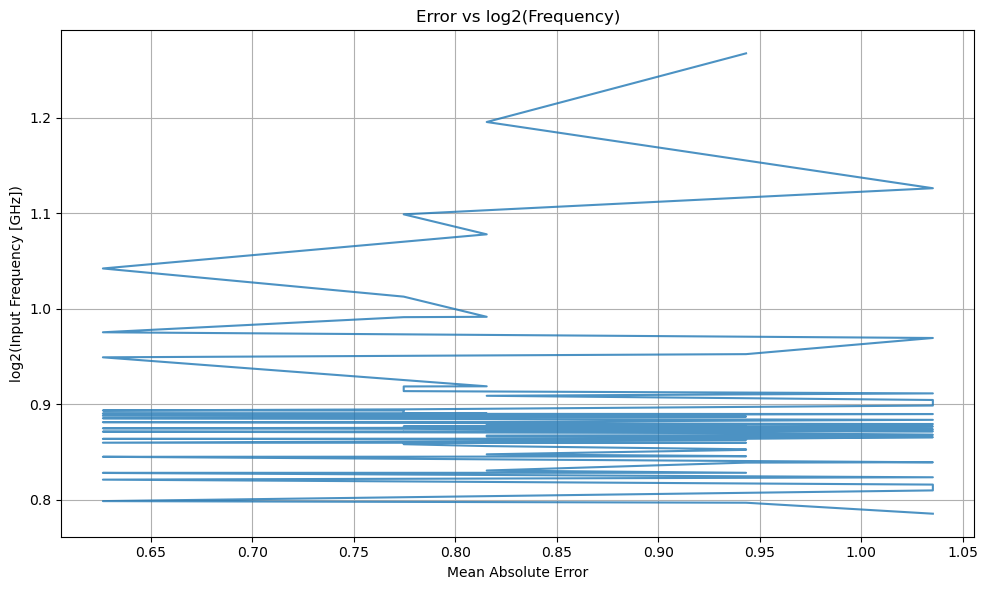

In [ ]:
#%%
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import torch as T
import pandas as pd
from scipy import signal
from scipy.io import savemat
import math


# ------------------- Helper Functions ----------------------

def get_data_in_array(dataframe, header_name, delim=True, size=400):
    _results_array = np.zeros([len(dataframe), size])
    for i in range(len(dataframe)):
        _results = dataframe[header_name].iloc[i].strip()[1:-1]
        _results = _results.split(",") if delim else _results.split()
        np_array = [float(value.strip()) for value in _results]
        _results_array[i] = np.array(np_array)[:400]
    return _results_array


def get_data(path): 
    dataset = pd.read_csv(path, skiprows=[0], names=['Numbers','Frequencies','Powers','arcsin_results','test_data','expected_recovered_freq'])
    dataset = dataset.sort_values(by=['Frequencies','Powers'], ignore_index=True)
    dataset = dataset.drop_duplicates(subset=['Frequencies','Powers'], keep='first', ignore_index=True)

    x = get_data_in_array(dataframe=dataset, header_name='arcsin_results', delim=True).astype(float)
    x = np.resize(x, (x.shape[0], 400))

    test_data = get_data_in_array(dataframe=dataset, header_name='test_data', delim=True).astype(float)
    test_data = np.resize(test_data, (test_data.shape[0], 400))

    return x, test_data, dataset


def normalize_vector(data):
    denom = np.sqrt(np.mean(np.square(data), axis=1, keepdims=True))
    return data / denom


# ------------------- Main Execution ------------------------

if __name__ == '__main__':
    # Load dataset
    input_data1, test_data1, datasets = get_data('pvary_fvary_offline.csv')

    # Normalize input data
    input_data1 = normalize_vector(input_data1)

    # Load traced model
    model = T.jit.load('best_model.pt')
    model.eval()

    # Convert input to tensor
    data = T.tensor(input_data1, dtype=T.float32).to('cuda:0')

    # Run inference
    outputs = model(data).cpu().detach().numpy()

    # Compute per-sample MSE
    error_per_sample = np.mean(np.abs(outputs - test_data1), axis=1)


    # Sort errors for visualization
    sorted_indices = np.argsort(error_per_sample)
    error_sorted = error_per_sample[sorted_indices]
    freqs_sorted = datasets['Frequencies'].to_numpy()[sorted_indices]

    # ------------------- Plotting ------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(freqs_sorted, error_sorted, alpha=0.8)    
    plt.xlabel('Mean Absolute Error')
    plt.ylabel('log2(Input Frequency [GHz])')
    plt.title('Error vs log2(Frequency)')   
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Power -20 dBm:
Maximum error: 0.08138020833333333
Mean error: 0.003338675213675213
Minimum error: 0.0

Power -10 dBm:
Maximum error: 0.0
Mean error: 0.0
Minimum error: 0.0

Power 0 dBm:
Maximum error: 0.0
Mean error: 0.0
Minimum error: 0.0

Power 10 dBm:
Maximum error: 0.0
Mean error: 0.0
Minimum error: 0.0

Power 14 dBm:
Maximum error: 0.0032552083333333335
Mean error: 4.173344017094017e-05
Minimum error: 0.0


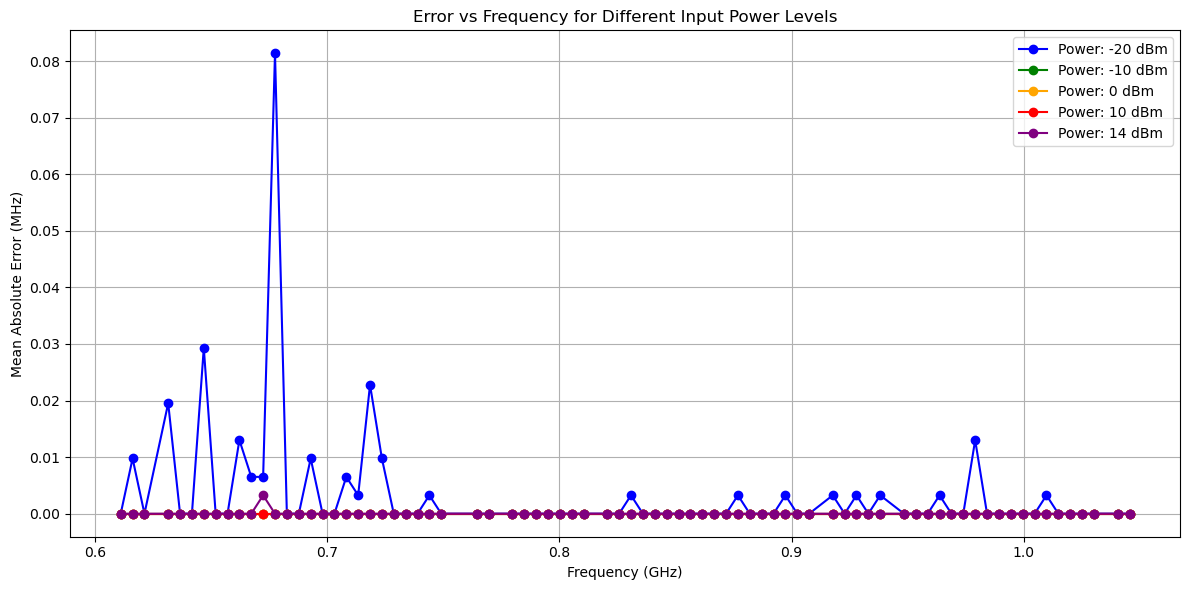

In [ ]:
def get_datasets(dataset):

    x = get_data_in_array(dataframe=dataset,header_name='arcsin_results',delim = True).astype(float)
    y = get_data_in_array(dataframe=dataset,header_name='test_data',delim = True).astype(float)

    x = np.resize(x, (x.shape[0], 400))
    y = np.resize(y, (y.shape[0], 400))

    data_tensor = T.tensor(x,dtype=T.float)
    targets_tensor = T.tensor(y,dtype=T.float)

    testing_dataset = T.utils.data.TensorDataset(data_tensor, targets_tensor)
    testing_loader = T.utils.data.DataLoader(testing_dataset, batch_size=1, shuffle=False)
    freqs=dataset['Frequencies']

    return testing_loader,freqs

def get_frequency_component(y):  #Function to obtain the frequency component of the signal

    y = y.view(-1).cpu().numpy()

    fs=2*(10**9) #Sampling Frequency=2GHz
    N=4*(2**(math.ceil(np.log2(len(y))))) #No. of samples in the FFT
    f, px = signal.periodogram(y, window='hann', nfft = N, fs=fs, scaling='spectrum')

    return f[np.argmax(px)]/(10**6)

def get_errors(loaded_model,device,testing_loader,freqs):

    loaded_model.eval()
    loaded_model.to(device)

    freq_dict = {}
    meanlist = []
    prevfreq = None

    with T.no_grad():
        for i, (data, target) in enumerate(testing_loader):
            data = data.to(device)
            target = target.to(device)

            output = loaded_model(data)

            f_true = get_frequency_component(target)
            f_pred = get_frequency_component(output)

            current_freq = freqs[i]

            if current_freq != prevfreq:
                if prevfreq is not None:
                    freq_dict[prevfreq] = np.mean(meanlist)
                    meanlist = []
                prevfreq = current_freq

            meanlist.append(abs(f_true - f_pred))

        # Save final group
        if prevfreq is not None:
            freq_dict[prevfreq] = np.mean(meanlist)

    return freq_dict

def plot_freq_vs_error(path):

    loaded_model = T.jit.load(path)
    device = T.device('cuda' if T.cuda.is_available() else 'cpu')

    # Load full dataset once
    dataset = pd.read_csv('pvary_fvary_train.csv',skiprows=[0],names=['Numbers', 'Frequencies', 'Powers', 'arcsin_results', 'test_data', 'expected_recovered_freq'])

    power_levels = [-20,-10,0,10,14]
    color_map = {-20:'blue', -10:'green', 0:'orange', 10:'red', 14:'purple'}

    plt.figure(figsize=(12, 6))

    for p in power_levels:
        
        power_filtered = dataset[dataset['Powers'] == p].reset_index(drop=True)

        testing_loader, freqs = get_datasets(power_filtered)

        freq_dict = get_errors(loaded_model, device, testing_loader, freqs)

        freqs_sorted, errors_sorted = zip(*sorted(freq_dict.items()))

        plt.plot(freqs_sorted, errors_sorted, marker='o', linestyle='-', color=color_map[p], label=f'Power: {p} dBm')

        print(f"\nPower {p} dBm:")
        print("Maximum error:", np.max(errors_sorted))
        print("Mean error:", np.mean(errors_sorted))
        print("Minimum error:", np.min(errors_sorted))

    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Mean Absolute Error (MHz)")
    plt.title("Error vs Frequency for Different Input Power Levels")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig("combined_error_vs_frequency_by_power_sweep_best_params_test.png", dpi=300)
    plt.show()

plot_freq_vs_error('best_model.pt')

In [ ]:
df = pd.read_csv('pvary_fvary_offline.csv')
df['Powers'].unique()

array([-20, -18, -16, -14, -12, -10,  -8,  -6,  -4,  -2,   0,   2,   4,
         6,   8,  10,  12,  14], dtype=int64)


Power -20 dBm:
Maximum error: 8.824869791666663
Mean error: 4.490234374999999
Minimum error: 1.9596354166666667

Power -10 dBm:
Maximum error: 9.697265624999986
Mean error: 4.86263020833333
Minimum error: 2.6399739583333335

Power -6 dBm:
Maximum error: 8.948567708333318
Mean error: 4.869791666666663
Minimum error: 2.7083333333333335

Power -4 dBm:
Maximum error: 9.973958333333318
Mean error: 5.63216145833333
Minimum error: 3.2486979166666647

Power -2 dBm:
Maximum error: 11.061197916666648
Mean error: 6.880208333333329
Minimum error: 3.863932291666664

Power 0 dBm:
Maximum error: 11.764322916666648
Mean error: 7.604817708333329
Minimum error: 4.560546874999997

Power 2 dBm:
Maximum error: 12.565104166666645
Mean error: 8.693359374999995
Minimum error: 5.074869791666661

Power 4 dBm:
Maximum error: 12.529296874999979
Mean error: 9.61979166666666
Minimum error: 4.986979166666661

Power 12 dBm:
Maximum error: 15.006510416666666
Mean error: 12.362630208333327
Minimum error: 9.12109374999

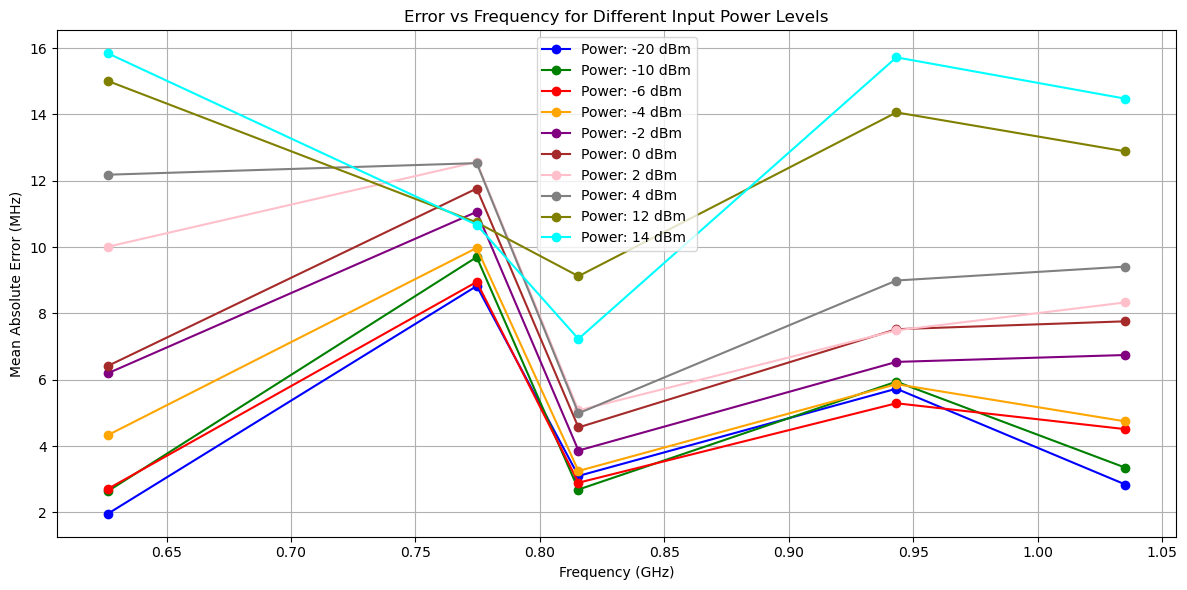

In [ ]:
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import torch as T
import pandas as pd
from scipy import signal
import math

# ------------------- Helper Functions ----------------------

def get_data_in_array(dataframe, header_name, delim=True, size=400):
    _results_array = np.zeros([len(dataframe), size])
    for i in range(len(dataframe)):
        _results = dataframe[header_name].iloc[i].strip()[1:-1]
        _results = _results.split(",") if delim else _results.split()
        np_array = [float(value.strip()) for value in _results]
        _results_array[i] = np.array(np_array)[:400]
    return _results_array

def get_datasets(dataset):
    x = get_data_in_array(dataframe=dataset, header_name='arcsin_results', delim=True).astype(float)
    y = get_data_in_array(dataframe=dataset, header_name='test_data', delim=True).astype(float)

    x = np.resize(x, (x.shape[0], 400))
    y = np.resize(y, (y.shape[0], 400))

    data_tensor = T.tensor(x, dtype=T.float32)
    targets_tensor = T.tensor(y, dtype=T.float32)

    testing_dataset = T.utils.data.TensorDataset(data_tensor, targets_tensor)
    testing_loader = T.utils.data.DataLoader(testing_dataset, batch_size=1, shuffle=False)
    freqs = dataset['Frequencies'].reset_index(drop=True)

    return testing_loader, freqs

def get_frequency_component(y):
    y = y.view(-1).cpu().numpy()
    fs = 2e9  # Sampling frequency = 2 GHz
    N = 4 * 2**math.ceil(np.log2(len(y)))
    f, px = signal.periodogram(y, window='hann', nfft=N, fs=fs, scaling='spectrum')
    return f[np.argmax(px)] / 1e6  # return in GHz

def get_errors(loaded_model, device, testing_loader, freqs):
    loaded_model.eval()
    loaded_model.to(device)

    freq_dict = {}
    meanlist = []
    prevfreq = None

    with T.no_grad():
        for i, (data, target) in enumerate(testing_loader):
            data = data.to(device)
            target = target.to(device)

            output = loaded_model(data)

            f_true = get_frequency_component(target)
            f_pred = get_frequency_component(output)

            current_freq = freqs[i]

            if current_freq != prevfreq:
                if prevfreq is not None:
                    freq_dict[prevfreq] = np.mean(meanlist)
                    meanlist = []
                prevfreq = current_freq

            meanlist.append(abs(f_true - f_pred))

        if prevfreq is not None:
            freq_dict[prevfreq] = np.mean(meanlist)

    return freq_dict

# ------------------- Main Plotting ------------------------

def plot_freq_vs_error(path):
    loaded_model = T.jit.load(path)
    device = T.device('cuda' if T.cuda.is_available() else 'cpu')

    dataset = pd.read_csv(
        'pvary_fvary_offline.csv',
        skiprows=[0],
        names=['Numbers', 'Frequencies', 'Powers', 'arcsin_results', 'test_data', 'expected_recovered_freq']
    )

    powers = [-20, -10, -6, -4, -2, 0, 2, 4, 12, 14]

    color_map = [
        'blue', 'green', 'red', 'orange', 'purple', 'brown',
        'pink', 'gray', 'olive', 'cyan']

    plt.figure(figsize=(12, 6))

    for i, p in enumerate(powers):
        df_power = dataset[dataset['Powers'] == p].reset_index(drop=True)

        if df_power.empty:
            continue  # Skip if no samples for this power level

        testing_loader, freqs = get_datasets(df_power)
        freq_dict = get_errors(loaded_model, device, testing_loader, freqs)

        freqs_sorted, errors_sorted = zip(*sorted(freq_dict.items()))
        plt.plot(freqs_sorted, errors_sorted, marker='o', linestyle='-', color=color_map[i], label=f'Power: {p} dBm')

        print(f"\nPower {p} dBm:")
        print("Maximum error:", np.max(errors_sorted))
        print("Mean error:", np.mean(errors_sorted))
        print("Minimum error:", np.min(errors_sorted))

    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Mean Absolute Error (MHz)")
    plt.title("Error vs Frequency for Different Input Power Levels (with offline data)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("combined_error_vs_frequency_by_power_sweep_best_params_test.png", dpi=300)
    plt.show()

# ------------------- Run ------------------------

plot_freq_vs_error('best_model.pt')
